## Testing different models accuracy and speed

In [1]:
from queue import Queue
import time, threading
import whisper
from faster_whisper import WhisperModel

c:\Users\HP\Saved Games\android\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_whisper_model(model_name, result_queue):
    """Load regular Whisper model and measure time"""
    start_time = time.time() * 1000  # Convert to milliseconds
    model = whisper.load_model(model_name)
    end_time = time.time() * 1000
    result_queue.put(("whisper_model_load", model, end_time - start_time))

def load_faster_whisper_model(model_name, result_queue):
    """Load faster-whisper model and measure time"""
    start_time = time.time() * 1000
    model = WhisperModel(model_name)
    end_time = time.time() * 1000
    result_queue.put(("faster_whisper_model_load", model, end_time - start_time))


In [3]:
def transcribe_whisper_audio(model, audio_file, result_queue):
    """Transcribe audio with regular Whisper and measure time"""
    start_time = time.time() * 1000
    result = model.transcribe(audio_file)
    end_time = time.time() * 1000
    result_queue.put(("whisper_transcription", result, end_time - start_time))

def transcribe_faster_whisper_audio(model, audio_file, result_queue):
    """Transcribe audio with faster-whisper and measure time"""
    start_time = time.time() * 1000
    segments, info = model.transcribe(audio_file)
    # Convert segments to text (faster-whisper returns generator)
    text = " ".join([segment.text for segment in segments])
    result = {"text": text, "language": info.language}
    end_time = time.time() * 1000
    result_queue.put(("faster_whisper_transcription", result, end_time - start_time))


In [4]:
# Audio file path
audio_file = "test_audio/count_down_test.mp3"  # Update with your audio file path
model_size = "tiny"  # You can change this to "small", "medium", etc.

print("=== Whisper Performance Comparison ===\n")

# Create queues for results
result_queue = Queue()

=== Whisper Performance Comparison ===



In [8]:
# === REGULAR WHISPER ===
print("1. Testing Regular Whisper...")

# Load regular Whisper model
print(f"Loading Whisper '{model_size}' model...")
whisper_model_thread = threading.Thread(target=load_whisper_model, args=(model_size, result_queue))
whisper_model_thread.start()
whisper_model_thread.join()

operation, whisper_model, whisper_model_load_time = result_queue.get()
print(f"✓ Whisper model loading took: {whisper_model_load_time:.2f} ms")

# Transcribe with regular Whisper
print("Transcribing with Whisper...")
whisper_transcribe_thread = threading.Thread(target=transcribe_whisper_audio, args=(whisper_model, audio_file, result_queue))
whisper_transcribe_thread.start()
whisper_transcribe_thread.join()

operation, whisper_result, whisper_transcribe_time = result_queue.get()
print(f"✓ Whisper transcription took: {whisper_transcribe_time:.2f} ms")

1. Testing Regular Whisper...
Loading Whisper 'tiny' model...
✓ Whisper model loading took: 480.01 ms
Transcribing with Whisper...
✓ Whisper transcription took: 743.01 ms


In [7]:
# === FASTER-WHISPER ===
print(f"\n2. Testing Faster-Whisper...")

# Load faster-whisper model
print(f"Loading Faster-Whisper '{model_size}' model...")
faster_whisper_model_thread = threading.Thread(target=load_faster_whisper_model, args=(model_size, result_queue))
faster_whisper_model_thread.start()
faster_whisper_model_thread.join()

operation, faster_whisper_model, faster_whisper_model_load_time = result_queue.get()
print(f"✓ Faster-Whisper model loading took: {faster_whisper_model_load_time:.2f} ms")

# Transcribe with faster-whisper
print("Transcribing with Faster-Whisper...")
faster_whisper_transcribe_thread = threading.Thread(target=transcribe_faster_whisper_audio, args=(faster_whisper_model, audio_file, result_queue))
faster_whisper_transcribe_thread.start()
faster_whisper_transcribe_thread.join()

operation, faster_whisper_result, faster_whisper_transcribe_time = result_queue.get()
print(f"✓ Faster-Whisper transcription took: {faster_whisper_transcribe_time:.2f} ms")



2. Testing Faster-Whisper...
Loading Faster-Whisper 'tiny' model...
✓ Faster-Whisper model loading took: 481.00 ms
Transcribing with Faster-Whisper...
✓ Faster-Whisper transcription took: 1659.78 ms


In [9]:
# === RESULTS COMPARISON ===
print("\n" + "="*50)
print("PERFORMANCE COMPARISON RESULTS")
print("="*50)

print(f"\nModel Loading Times:")
print(f"  Regular Whisper:   {whisper_model_load_time:.2f} ms")
print(f"  Faster-Whisper:    {faster_whisper_model_load_time:.2f} ms")
model_speedup = whisper_model_load_time / faster_whisper_model_load_time
print(f"  Speedup:           {model_speedup:.2f}x {'faster' if model_speedup > 1 else 'slower'}")

print(f"\nTranscription Times:")
print(f"  Regular Whisper:   {whisper_transcribe_time:.2f} ms")
print(f"  Faster-Whisper:    {faster_whisper_transcribe_time:.2f} ms")
transcribe_speedup = whisper_transcribe_time / faster_whisper_transcribe_time
print(f"  Speedup:           {transcribe_speedup:.2f}x {'faster' if transcribe_speedup > 1 else 'slower'}")

print(f"\nTotal Times:")
whisper_total = whisper_model_load_time + whisper_transcribe_time
faster_whisper_total = faster_whisper_model_load_time + faster_whisper_transcribe_time
print(f"  Regular Whisper:   {whisper_total:.2f} ms")
print(f"  Faster-Whisper:    {faster_whisper_total:.2f} ms")
total_speedup = whisper_total / faster_whisper_total
print(f"  Overall Speedup:   {total_speedup:.2f}x {'faster' if total_speedup > 1 else 'slower'}")



PERFORMANCE COMPARISON RESULTS

Model Loading Times:
  Regular Whisper:   480.01 ms
  Faster-Whisper:    481.00 ms
  Speedup:           1.00x slower

Transcription Times:
  Regular Whisper:   743.01 ms
  Faster-Whisper:    1659.78 ms
  Speedup:           0.45x slower

Total Times:
  Regular Whisper:   1223.02 ms
  Faster-Whisper:    2140.78 ms
  Overall Speedup:   0.57x slower


### The denoising model and how to use it

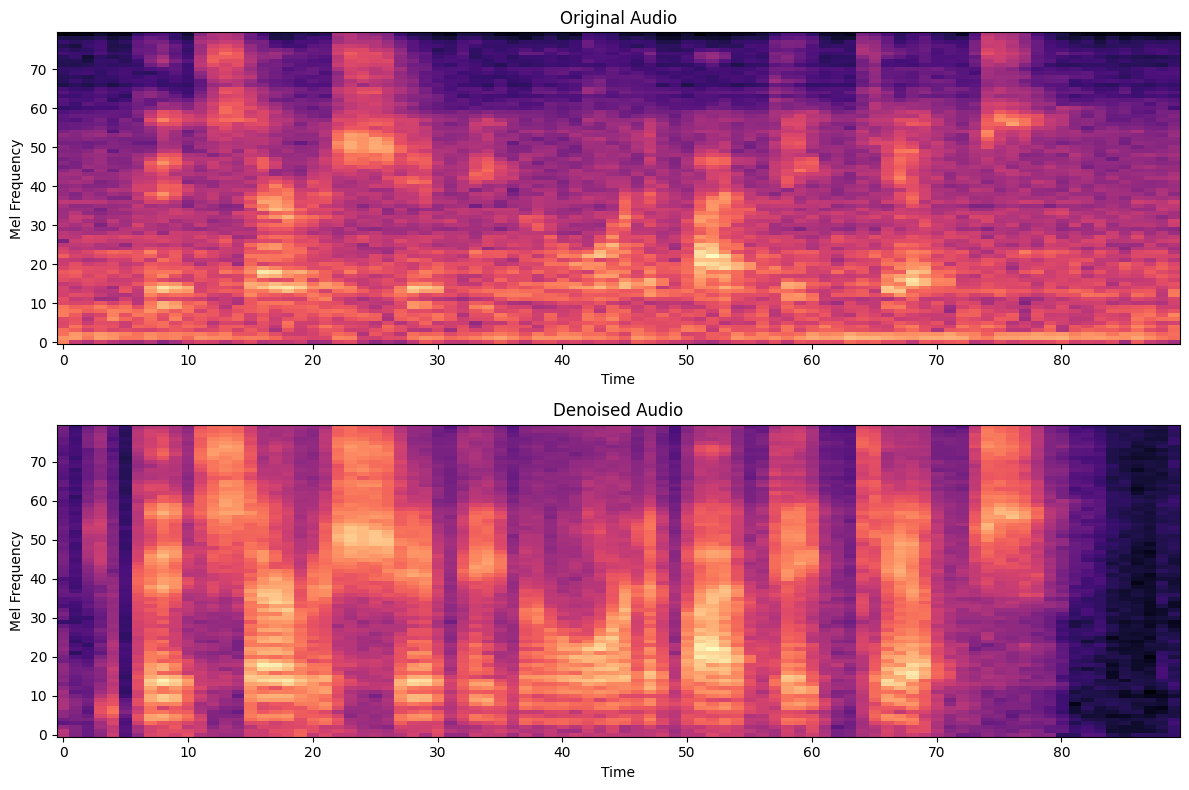

In [5]:
from IPython import display as disp
import torch
import torchaudio
import matplotlib.pyplot as plt
from denoiser import pretrained
from denoiser.dsp import convert_audio

# Load and denoise audio
path = "noisy_audio/data/Noisy_Recordings/bigtips_factoryr1_16.wav"
model = pretrained.dns64()
wav, sr = torchaudio.load(path)
wav = convert_audio(wav, sr, model.sample_rate, model.chin)

with torch.no_grad():
    denoised = model(wav[None])[0]

# Play original and denoised audio
disp.display(disp.Audio(wav.data.cpu().numpy(), rate=model.sample_rate))
disp.display(disp.Audio(denoised.data.cpu().numpy(), rate=model.sample_rate))

# Save denoised audio (optional)
torchaudio.save("denoised_output.wav", denoised, model.sample_rate)

# Function to plot spectrogram
def plot_spectrogram(audio_tensor, sample_rate, title, ax):
    spectrogram = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=1024,
        hop_length=512,
        n_mels=80
    )(audio_tensor)
    spectrogram_db = torchaudio.transforms.AmplitudeToDB()(spectrogram)
    ax.set_title(title)
    ax.imshow(spectrogram_db.squeeze().cpu().numpy(), aspect="auto", origin="lower", cmap="magma")
    ax.set_xlabel("Time")
    ax.set_ylabel("Mel Frequency")

# Plot original vs denoised spectrograms
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_spectrogram(wav[0], model.sample_rate, "Original Audio", axes[0])
plot_spectrogram(denoised[0], model.sample_rate, "Denoised Audio", axes[1])
plt.tight_layout()
plt.show()
